In [1]:
import numpy as np
import qiskit as qis

from qiskit.quantum_info.operators.random import * 
from qiskit_aer.backends import AerSimulator
from qiskit.quantum_info import *

import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.visualization import plot_histogram, plot_bloch_multivector

from matplotlib.pyplot import figure
import itertools


%pylab inline

"""Code elements for the mapping procedure"""

def extractvariables(expr):
    """Recursively extract unique variables from a logical expression."""
    variables = set()
    if isinstance(expr, list):
        for subexpr in expr[1:]:  # Skip the connective at index 0
            variables.update(extractvariables(subexpr))
    elif isinstance(expr, str):
        variables.add(expr)
    return variables

def countconnectives(expr):
    """Recursively count logical connectives in a logical expression."""
    count = 0
    if isinstance(expr, list):
        count += 1  # Count this connective
        for subexpr in expr[1:]:  # Skip the connective at index 0
            count += countconnectives(subexpr)
    return count

def resolveexpression(expr, circuit, qubitsmap, ancillastart, ancillacounter):
    """
    Recursively resolve logical expressions into quantum gates.
    Returns the qubit index storing this subexpression's result.
    """
    if isinstance(expr, str):  # It's a variable
        return qubitsmap[expr]

    gate = expr[0]  # Logical connective
    args = expr[1:]

    # Recursively resolve arguments
    resolved_args = [resolveexpression(arg, circuit, qubitsmap, ancillastart, ancillacounter) for arg in args]
    target = ancillastart + ancillacounter[0]
    ancillacounter[0] += 1  # Increment counter

    # Apply quantum gates for each logical connective
    if gate == "not" and len(resolved_args) == 1:
        circuit.x(resolved_args[0])
        circuit.cx(resolved_args[0], target)
    elif gate == "and" and len(resolved_args) == 2:
        q1, q2 = resolved_args
        circuit.ccx(q1, q2, target)
    elif gate == "or" and len(resolved_args) == 2:
        q1, q2 = resolved_args
        circuit.cx(q1, target)
        circuit.cx(q2, target)
        circuit.ccx(q1, q2, target)
    elif gate == "xor" and len(resolved_args) == 2:
        q1, q2 = resolved_args
        circuit.cx(q1, target)
        circuit.cx(q2, target)
    elif gate == "implication" and len(resolved_args) == 2:
        q1, q2 = resolved_args
        circuit.x(q1)
        circuit.cx(q1, target)
        circuit.x(q1)
        circuit.cx(q2, target)
    elif gate == "bijection" and len(resolved_args) == 2:
        q1, q2 = resolved_args
        circuit.cx(q1, target)
        circuit.cx(q2, target)
        circuit.x(target)
    else:
        raise ValueError(f"Unknown or improperly formatted gate: {gate}")

    return target

"""The mapping procedure"""

def logicaltoquantum(expression):
    """
    Maps a logical expression to a quantum circuit with dynamic qubit allocation.
    Returns the circuit and the variable-to-qubit mapping.
    """
    """Automatically maps logical expressions to quantum circuits with dynamic qubit allocation."""
    # Extract variables and count connectives
    variables = extractvariables(expression)
    num_ancilla = countconnectives(expression)

    # Dynamic Qubit Mapping
    var_list = sorted(list(variables))  #sort the variables
    qubitsmap = {var: idx for idx, var in enumerate(var_list)} #get the qubits from the no. of variables
    ancilla_start = len(qubitsmap) #have the ancillas properly sorted
    ancilla_map = {f"anc{i+1}": ancilla_start + i for i in range(num_ancilla)}    #get the qubits from the no. of ancillas
    qubitsmap.update(ancilla_map)  #update the no. of qubits

    # Create Quantum Register with Named Qubits

    circuit = QuantumCircuit()
    for name in sorted(variables):
        qreg = QuantumRegister(1, name=name)
        circuit.add_register(qreg)
        
    anc_reg = QuantumRegister(num_ancilla, name = "anc")
    """out_reg = ClassicalRegister(1, name = "OUT")
    circuit.add_register(anc_reg, out_reg)"""
    circuit.add_register(anc_reg)
        
    #qreg = QuantumRegister(len(qubits_map), name="q")
    #creg = ClassicalRegister(1, name="OUT")
    #circuit = QuantumCircuit(qreg, creg) #generate the quantum registers and circuit based on the no. of variables + ancillas
    
    
    #Add Hadamard Gates to Basis Qubits to create superposition
    basis_qubits = set(range(len(variables)))  # Indices of the logical variables
    for q in basis_qubits:
        circuit.h(q)  # Apply Hadamard to each basis qubit

    # Resolve the expression
    ancilla_counter = [0]  # Use a list to keep the counter mutable
    final_result = resolveexpression(expression, circuit, qubitsmap, ancilla_start, ancilla_counter)
    #print(f"Final result stored in qubit: {final_result}")  #show where do we store the final qubit
    
    return circuit, qubitsmap


"""Formula evaluation for truth probabilities of 0 and 1 states"""

def eval_formula(formula, assignment):
    if isinstance(formula, str):  # variable
        return assignment[formula]
    op = formula[0]
    if op == 'not':
        return 1 - eval_formula(formula[1], assignment)
    elif op == 'and':
        return eval_formula(formula[1], assignment) * eval_formula(formula[2], assignment)
    elif op == 'or':
        return max(eval_formula(formula[1], assignment), eval_formula(formula[2], assignment))
    elif op == 'implication':
        left = eval_formula(formula[1], assignment)
        right = eval_formula(formula[2], assignment)
        return max(1 - left, right)   # (¬left) ∨ right
    elif op == 'xor':
        left = eval_formula(formula[1], assignment)
        right = eval_formula(formula[2], assignment)
        return (left + right) % 2
    elif op == 'bijection':  # logical equivalence
        left = eval_formula(formula[1], assignment)
        right = eval_formula(formula[2], assignment)
        return 1 if left == right else 0
    else:
        raise ValueError(f"Unknown operator {op}")

def formula_probability(formula, variables):
    probs = {var: 0.5 for var in sorted(variables)}
    vars_ = list(probs.keys())
    total = 0.0
    for values in itertools.product([0,1], repeat=len(vars_)):
        assignment = dict(zip(vars_, values))
        # joint probability under independence
        p = 1.0
        for v in vars_:
            p *= probs[v] if assignment[v] == 1 else (1 - probs[v])
        if eval_formula(formula, assignment):
            total += p
    return total

"""Oracle and diffusion operators for amplitude amplification"""

def amplification_rounds(formula, variables):
    c1 = formula_probability(formula, variables)
    if (1-c1) < c1:
        rounds = int(np.floor(np.pi/4 * np.sqrt(1/(1-c1))))
        prob = 1-c1
    else:
        rounds = int(np.floor(np.pi/4 * np.sqrt(1/(c1))))
        prob = c1

    return rounds, prob


def oracle_generate(input_circ, prob):
    len = input_circ.num_qubits
    orac = QuantumCircuit(len)
    if 1-prob < prob:
        orac.x(len - 1)
        orac.z(len - 1)
        orac.x(len - 1)
    else:
        orac.z(len - 1)

    return orac

def diffusion_generate(input_circ):
    len = input_circ.num_qubits
    b1 = QuantumCircuit(len)
    b2 = b1.compose(input_circ.inverse())

    for qubit in range(len ):
        b2.x(qubit)

    b2.h(len - 1)
    b2.mcx(list(range(0, len - 1)), len - 1)
    b2.h(len - 1)

    for qubit in range(len ):
        b2.x(qubit)

    diffusion = b2.compose(input_circ)

    return diffusion

"""Applying Oracle and diffusion operators iteratively"""

def apply_operators(circuit, oracle, amplifier, rounds):
    for _ in range(rounds):
        circuit = circuit.compose(oracle).compose(amplifier)

    return circuit


def generate_amplified_circuits(base_circuit, oracle, diffuser, max_rounds):
    amplified_circuits = {0: base_circuit}
    for i in range(1, max_rounds + 1):
        amplified_circuits[i] = apply_operators(amplified_circuits[i-1], oracle, diffuser, 1)
    return amplified_circuits


%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


C:\Users\Botond\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.9_qbz5n2kfra8p0\LocalCache\local-packages\Python39\site-packages\IPython\core\magics\pylab.py:162: UserWarning: pylab import has clobbered these variables: ['random']
`%matplotlib` prevents importing * from pylab and numpy
  warn("pylab import has clobbered these variables: %s"  % clobbered +


Qubit Mapping: {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'anc1': 4, 'anc2': 5, 'anc3': 6, 'anc4': 7, 'anc5': 8}
The variable qubits: {'C', 'B', 'D', 'A'}


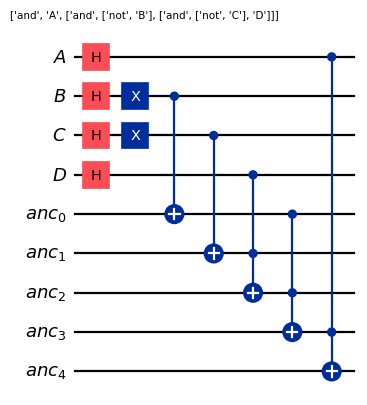

In [2]:
# Example Logical Expression
formula = ['and', 'A',['and',['not', 'B'],['and',['not', 'C'],'D']]]

# Generate Quantum Circuit with Dynamic Qubit Allocation
qc, qubits_map = logicaltoquantum(formula)
print("Qubit Mapping:", qubits_map)

variable_qubits = extractvariables(formula)
print("The variable qubits:", variable_qubits)

fig = figure()
ax = fig.add_subplot()

ax.set_title(formula, fontsize=7.5, loc = 'left')

qc.draw('mpl', ax = ax)  # Draw the circuit

In [3]:
good_state_prob = formula_probability(formula, variable_qubits)
print("The probability of obtaining state '1' is:", good_state_prob)

The probability of obtaining state '1' is: 0.0625


In [4]:
rounds, good_state_prob = amplification_rounds(formula, variable_qubits)
print("The probability of obtaining the good state is: P =", good_state_prob)
print("Thus the number of rotations needed for near perfect amplification is: k =", rounds)

The probability of obtaining the good state is: P = 0.0625
Thus the number of rotations needed for near perfect amplification is: k = 3


In [5]:
amplified_circuits = generate_amplified_circuits(qc, oracle_generate(qc, good_state_prob), 
                                                 diffusion_generate(qc), rounds)

In [6]:
# make a copy so original isn't modified
amplified_circuits_copy = amplified_circuits.copy()
amplified_circuits_copy

{0: <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x23c1d59fbb0>,
 1: <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x23c6eeebcd0>,
 2: <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x23c6eefb070>,
 3: <qiskit.circuit.quantumcircuit.QuantumCircuit at 0x23c6eefb430>}

In [7]:
sim = AerSimulator(method="matrix_product_state")
N_shots = 1000000  # number of measurements

circuit_measurements = {}
prob_values = {}
counts = {}
res = {}

for i, circ in amplified_circuits_copy.items():
    # add 1 classical bit to measure last qubit
    creg = ClassicalRegister(1)
    amplified_circuits_copy[i].add_register(creg)
    amplified_circuits_copy[i].measure(amplified_circuits_copy[i].num_qubits - 1, 0)

    # transpile
    circuit_measurements[i] = qis.transpile(amplified_circuits_copy[i], sim)

    # run simulation
    res[i] = sim.run(circuit_measurements[i], shots=N_shots, max_parallel_threads=16).result()
    counts[i] = res[i].get_counts()

    # normalize into probabilities
    prob_values[i] = {bit: count / N_shots for bit, count in counts[i].items()}

"""
for i in range (0, rounds):
    amplified_circuits[i].add_register(ClassicalRegister(1))
    amplified_circuits[i].measure(len(qubits_map)-1, 0)
    circuit_measurements[i] = qis.transpile(amplified_circuits[i], sim)

    res = sim.run(circuit_measurements, shots=N_shots, max_parallel_threads = 16).result()
    coun = res.get_counts()

    prob_values[i] = {bitstring: count / N_shots for bitstring, count in coun.items()}
"""

'\nfor i in range (0, rounds):\n    amplified_circuits[i].add_register(ClassicalRegister(1))\n    amplified_circuits[i].measure(len(qubits_map)-1, 0)\n    circuit_measurements[i] = qis.transpile(amplified_circuits[i], sim)\n\n    res = sim.run(circuit_measurements, shots=N_shots, max_parallel_threads = 16).result()\n    coun = res.get_counts()\n\n    prob_values[i] = {bitstring: count / N_shots for bitstring, count in coun.items()}\n'

In [8]:
prob_values

{0: {'0': 0.937296, '1': 0.062704},
 1: {'0': 0.52741, '1': 0.47259},
 2: {'1': 0.908558, '0': 0.091442},
 3: {'1': 0.961448, '0': 0.038552}}

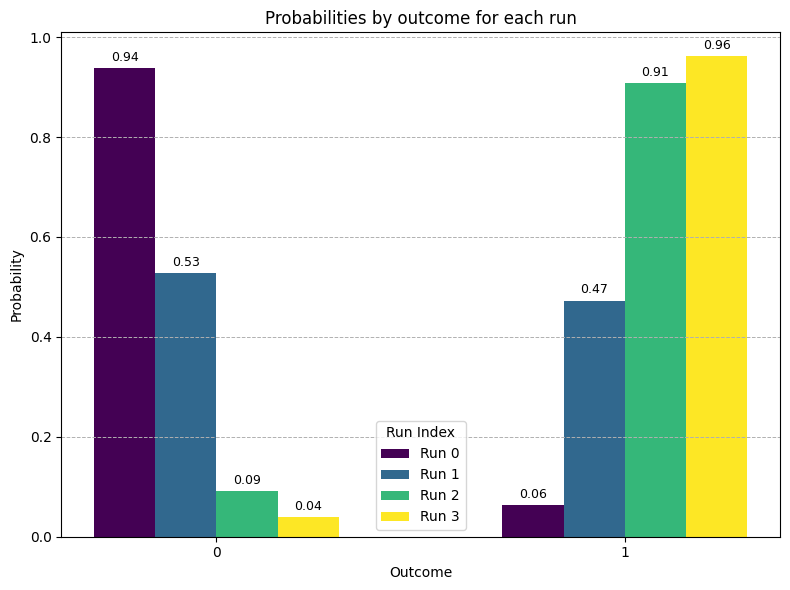

In [9]:
outcomes = ['0', '1']
runs = sorted(prob_values.keys())
num_runs = len(runs)
width = 0.15

x = np.arange(len(outcomes))

# Choose a color palette
colors = plt.cm.viridis(np.linspace(0, 1, num_runs))

fig, ax = plt.subplots(figsize=(8, 6))

bars = []
for idx, run in enumerate(runs):
    bar_values = [prob_values[run].get(o, 0) for o in outcomes]
    b = ax.bar(x + width*idx - width*num_runs/2 + width/2, bar_values, width, label=f'Run {run}', color=colors[idx])
    bars.append(b)

# Add bar labels
for b in bars:
    for rect in b:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),   # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(outcomes)
ax.set_xlabel('Outcome')
ax.set_ylabel('Probability')
ax.set_title('Probabilities by outcome for each run')
ax.grid(axis='y', linestyle='--', linewidth=0.7)
ax.legend(title='Run Index')

plt.tight_layout()
plt.show()


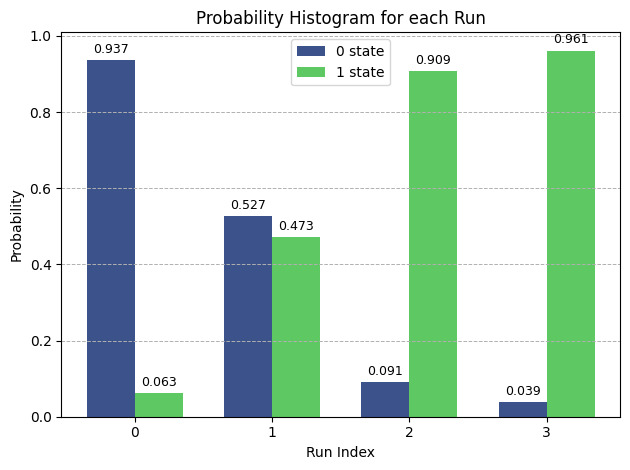

In [10]:
import matplotlib.pyplot as plt
import numpy as np

labels = sorted(prob_values.keys())  # run indices
x = np.arange(len(labels))           # x positions

probs_0 = [prob_values[i].get('0', 0) for i in labels]
probs_1 = [prob_values[i].get('1', 0) for i in labels]

width = 0.35

# Use continuous colormap for the two bar sets
colors = plt.cm.viridis(np.linspace(0.25, 0.75, 2))

fig, ax = plt.subplots()
rects0 = ax.bar(x - width/2, probs_0, width, label='0 state', color=colors[0])
rects1 = ax.bar(x + width/2, probs_1, width, label='1 state', color=colors[1])

# Add bar labels
for rect in rects0:
    height = rect.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

for rect in rects1:
    height = rect.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Run Index')
ax.set_ylabel('Probability')
ax.set_title('Probability Histogram for each Run')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Add grid mesh lines on y axis for readability
ax.grid(axis='y', linestyle='--', linewidth=0.7)

plt.tight_layout()
plt.show()
